#   LangGraph 활용 - Self RAG 

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings("ignore")

`(3) Langsmith tracing 설정`

In [3]:
# Langsmith tracing 여부를 확인 (true: langsmith 추척 활성화, false: langsmith 추척 비활성화)
import os
print(os.getenv('LANGSMITH_TRACING'))

true


---

## **Self-RAG**

- Self-RAG (Retrieval-Augmented Generation with Self-Reflection) 

- 주요 단계: 

   1. 검색 결정 (Retrieval Decision):
      - 입력: 질문 `x` 또는 질문 `x`와 생성된 답변 `y`
      - 목적: 검색기 `R`을 사용하여 `D` 개의 청크를 검색할지 결정
      - 출력: "yes", "no", "continue" 중 하나
      - 의미: 시스템이 추가 정보가 필요한지 판단

   2. 검색된 문서 관련성 평가:
      - 입력: 질문 `x`와 각 검색된 청크 `d`
      - 목적: 각 청크가 질문에 유용한 정보를 제공하는지 평가
      - 출력: "relevant" 또는 "irrelevant"
      - 의미: 관련 없는 정보를 필터링하여 품질을 향상

   3. 생성된 답변의 환각 평가:
      - 입력: 질문 `x`, 청크 `d`, 생성된 텍스트 `y`
      - 목적: 생성된 텍스트가 청크의 정보에 의해 지지되는지 평가
      - 출력: "fully supported", "partially supported", "no support"
      - 의미: 환각(hallucination)을 감지하고 정보의 신뢰성을 확인

   4. 생성된 답변의 유용성 평가:
      - 입력: 질문 `x`와 생성된 텍스트 `y`
      - 목적: 생성된 텍스트가 질문에 유용한 응답인지 평가
      - 출력: 5점 척도 (5: 매우 유용, 1: 전혀 유용하지 않음)
      - 의미: 응답의 품질과 관련성을 수치화

- 논문: https://arxiv.org/abs/2310.11511

### **1. 벡터저장소** 
- 레스토랑 메뉴 검색 시스템
- 메뉴 검색을 위해 저장해둔 저장소를 로드

In [4]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import List, Dict, Literal
import logging

# 로깅 설정
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class QueryAnalysis(BaseModel):
    """쿼리 분석 결과 모델"""
    complexity: Literal["simple", "medium", "complex"] = Field(
        description="쿼리의 복잡도 수준"
    )


class RestaurantMenuVectorStore:
    """레스토랑 메뉴 검색을 위한 벡터 저장소"""
    
    def __init__(self, collection_name: str, persist_dir: str = "./chroma_db"):

        # LLM 초기화
        self.llm = ChatOpenAI(
            model="gpt-4.1-nano",
            temperature=0
        )

        # 임베딩 모델 사용 
        self.embeddings = OpenAIEmbeddings(
            model="text-embedding-3-small",
            dimensions=1536  # 차원 설정
        )
        
        # Chroma DB 초기화
        self.vector_db = Chroma(
            embedding_function=self.embeddings,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
        
        # 쿼리 분석기 설정
        self._setup_query_analyzer()

        logger.info(f"✅ Vector store '{collection_name}' initialized")

    def _setup_query_analyzer(self):
        """쿼리 분석기 설정"""
        
        # 쿼리 분석 프롬프트
        analysis_prompt = ChatPromptTemplate.from_template("""
        다음 사용자 쿼리를 분석하여 복잡도와 검색 전략을 결정해주세요.

        사용자 쿼리: {query}

        분석 기준:
        - Simple: 단순한 메뉴 검색 (예: "스테이크 메뉴", "파스타 종류")
        - Medium: 조건이 있는 검색 (예: "매운 음식 추천", "채식주의자용 메뉴")
        - Complex: 다중 조건이나 추론이 필요한 검색 (예: "데이트하기 좋은 분위기의 와인과 어울리는 요리")
        """)
        
        # 쿼리 분석 체인 생성
        self.query_analyzer = analysis_prompt | self.llm.with_structured_output(QueryAnalysis)       
    
    def adaptive_search(self, query: str, k: int = None, score_threshold: float = None) -> List:
        """쿼리 복잡도에 따른 적응형 검색"""
        # 쿼리 복잡도 분석
        query_analysis = self.query_analyzer.invoke({"query": query})
        logger.info(f"🔍 쿼리 분석 결과: {query_analysis}")

        if k is None:
            # 쿼리 복잡도에 따라 검색 개수 동적 조정
            if query_analysis.complexity == "simple":
                k = 3
            elif query_analysis.complexity == "medium":
                k = 5
            else:
                k = 7

        self.retriever = self.vector_db.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs={
                "k": k,
                "score_threshold": score_threshold if score_threshold is not None else 0.
            }
        )

        # 검색 실행
        results = self.retriever.invoke(query)

        logger.info(f"📊 검색 완료: {len(results)}/{k} 문서 반환")
        return results

# 사용 예시
vector_db = RestaurantMenuVectorStore(collection_name="restaurant_menu")
results = vector_db.adaptive_search("스테이크와 메뉴를 추천해주세요.")

INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
INFO:__main__:✅ Vector store 'restaurant_menu' initialized
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:🔍 쿼리 분석 결과: complexity='simple'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:📊 검색 완료: 3/3 문서 반환


In [5]:
pprint(results)

[Document(id='a26e6bbd-54d7-4889-8ea8-acb234651883', metadata={'menu_name': '샤토브리앙 스테이크', 'source': './data/restaurant_menu.txt', 'menu_number': 26}, page_content='26. 샤토브리앙 스테이크\n    • 가격: ₩42,000\n    • 주요 식재료: 프리미엄 안심 스테이크, 푸아그라, 트러플 소스\n    • 설명: 최상급 안심 스테이크에 푸아그라를 올리고 트러플 소스를 곁들인 클래식 프렌치 요리입니다. 부드러운 육질과 깊은 풍미가 특징이며, 그린 아스파라거스와 감자 그라탕을 함께 제공합니다.'),
 Document(id='1d145cb1-ffff-4c37-9754-ac8c818aa4b2', metadata={'source': './data/restaurant_menu.txt', 'menu_name': '샤토브리앙 스테이크', 'menu_number': 26}, page_content='26. 샤토브리앙 스테이크\n    • 가격: ₩42,000\n    • 주요 식재료: 프리미엄 안심 스테이크, 푸아그라, 트러플 소스\n    • 설명: 최상급 안심 스테이크에 푸아그라를 올리고 트러플 소스를 곁들인 클래식 프렌치 요리입니다. 부드러운 육질과 깊은 풍미가 특징이며, 그린 아스파라거스와 감자 그라탕을 함께 제공합니다.'),
 Document(id='a2678240-3f97-45fd-a285-6029074dcf05', metadata={'source': './data/restaurant_menu.txt', 'menu_number': 26, 'menu_name': '샤토브리앙 스테이크'}, page_content='26. 샤토브리앙 스테이크\n    • 가격: ₩42,000\n    • 주요 식재료: 프리미엄 안심 스테이크, 푸아그라, 트러플 소스\n    • 설명: 최상급 안심 스테이크에 푸아그라를 올리고 트러플 소스를 곁들인 클래식 

### **2. Retrieval Grader** 

- 검색 평가자는 **키워드 관련성**과 **의미적 관련성**을 기준으로 결과를 평가

- 평가는 **'yes/no' 이진법**으로 진행하며 불확실한 경우 'no' 처리

- 부분 관련성이나 맥락 정보도 **답변 형성 기여도** 기준으로 평가

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Literal
import time


# 검색된 문서의 관련성 평가 결과를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """문서 관련성 평가 모델"""
    
    binary_score: Literal['yes', 'no'] = Field(
        description="문서가 질문과 관련있는지 여부"
    )
    confidence: float = Field(
        description="평가 신뢰도 (0-1)"
    )
    reasoning: str = Field(
        description="평가 근거"
    )

class RetrievalGrader:
    """검색 성능 평가자"""

    def __init__(self, model: str = "gpt-4.1-mini"):
        # LLM 초기화 (최신 모델)
        self.llm = ChatOpenAI(
            model=model,
            temperature=0,
            max_retries=3  # 재시도 설정
        )
        
        # 구조화된 출력 설정
        self.structured_llm = self.llm.with_structured_output(GradeDocuments)
        
        # 개선된 프롬프트
        self.system_prompt = """당신은 검색 품질 평가 전문가입니다.

        평가 기준:
        1. 키워드 매칭 (30%): 핵심 단어와 동의어 포함 여부
        2. 의미적 관련성 (40%): 문서의 주제와 질문의 의도 일치도
        3. 정보 가치 (30%): 답변 형성에 도움되는 정보 포함 여부

        신뢰도 점수:
        - 0.9-1.0: 매우 확실함
        - 0.7-0.9: 확실함
        - 0.5-0.7: 보통
        - 0.0-0.5: 불확실함

        평가 시 주의사항:
        - 부분적 관련성도 가치있게 평가
        - 간접적 정보도 고려
        - 과도한 엄격성 지양"""
        
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", self.system_prompt),
            ("human", """[검색된 문서]
{document}

[사용자 질문]
{question}

이 문서가 질문에 답하는데 도움이 되는지 평가해주세요."""),
        ])
        
        # 체인 구성
        self.chain = self.prompt | self.structured_llm
    
    def grade(self, question: str, document: str) -> GradeDocuments:
        """문서 관련성 평가"""
        start_time = time.time()
        
        try:
            result = self.chain.invoke({
                "question": question,
                "document": document
            })
            
            # 성능 로깅
            elapsed = time.time() - start_time
            logger.info(f"⏱️ 평가 시간: {elapsed:.2f}초 | 결과: {result.binary_score}")
            
            return result
            
        except Exception as e:
            logger.error(f"❌ 평가 실패: {str(e)}")
            # 실패 시 기본값 반환
            return GradeDocuments(
                binary_score="no",
                confidence=0.0,
                reasoning="평가 중 오류 발생"
            )

In [7]:
# 사용 예시
retrieval_grader = RetrievalGrader()

question = "이 식당의 시그니처 메뉴는?"
retrieved_docs = vector_db.adaptive_search(question, score_threshold=0.001)

for i, doc in enumerate(retrieved_docs):
    print(f"문서 {i + 1}: {doc.page_content[:100]}...")
    result = retrieval_grader.grade(
        question=question,
        document=doc.page_content
    )
    print(f"관련성: {result.binary_score}")
    print(f"신뢰도: {result.confidence:.2f}")
    print(f"근거: {result.reasoning}")
    print("-" * 30)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:🔍 쿼리 분석 결과: complexity='simple'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:📊 검색 완료: 3/3 문서 반환


문서 1: 1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, ...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.31초 | 결과: yes


관련성: yes
신뢰도: 0.95
근거: 문서에는 '시그니처 스테이크'라는 메뉴가 시그니처 메뉴임을 명확히 언급하고 있으며, 가격, 주요 식재료, 조리 방법, 곁들임 음식과 소스까지 상세히 설명하고 있어 질문에 대한 답변으로 매우 적합하다. 키워드 '시그니처 메뉴'와 의미적 관련성이 높고, 정보 가치도 풍부하다.
------------------------------
문서 2: 1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, ...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.37초 | 결과: yes


관련성: yes
신뢰도: 0.95
근거: 문서에는 '시그니처 스테이크'가 이 식당의 시그니처 메뉴임을 명확히 설명하고 있으며, 가격, 주요 식재료, 조리 방법, 곁들임 음식과 소스까지 상세히 기술되어 있어 질문에 매우 적합한 답변 정보를 제공한다. 키워드 '시그니처 메뉴'와 의미적 관련성이 높고, 정보 가치도 풍부하다.
------------------------------
문서 3: 1. 시그니처 스테이크
   • 가격: ₩35,000
   • 주요 식재료: 최상급 한우 등심, 로즈메리 감자, 그릴드 아스파라거스
   • 설명: 셰프의 특제 시그니처 메뉴로, ...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.27초 | 결과: yes


관련성: yes
신뢰도: 0.95
근거: 문서에는 '시그니처 스테이크'가 이 식당의 시그니처 메뉴임을 명확히 설명하고 있으며, 가격, 주요 식재료, 조리 방법, 곁들임 음식과 소스까지 상세히 기술되어 있어 질문에 대한 답변 형성에 매우 적합하다. 핵심 키워드인 '시그니처 메뉴'와 의미적으로도 완벽히 일치하며, 정보 가치도 높다.
------------------------------


### **3. Answer Generator** 

- **답변 생성** 시 문맥 내 정보만 사용하고 추측 배제
- **Chain-of-Though** 활용
- 답변은 **직접 관련 정보**만 포함하여 간결하게 작성
- 정보 부족 시 "**주어진 정보만으로는 답할 수 없습니다**" 명시
- 필요시 **직접 인용문** 활용하여 정확성 확보

In [8]:
from langchain_core.output_parsers import StrOutputParser
from typing import List, Dict, Optional
import json

class AnswerGenerator:
    """답변 생성기"""
    
    def __init__(self, model: str = "gpt-4.1-mini"):
        self.llm = ChatOpenAI(model=model, temperature=0.3)
        
        # 프롬프트
        self.template = """당신은 정확하고 도움되는 답변을 제공하는 AI 어시스턴트입니다.

        [지침]
        1. 제공된 문맥만을 사용하여 답변
        2. 불확실한 경우 명확히 표시
        3. 간결하되 완전한 답변 제공

        [문맥]
        {context}

        [질문]
        {question}

        [답변]"""
        
        self.prompt = ChatPromptTemplate.from_template(self.template)
        self.chain = self.prompt | self.llm | StrOutputParser()
    
    def generate(
        self, 
        question: str, 
        documents: List[Dict],
        metadata: Optional[Dict] = None
    ) -> Dict:
        """컨텍스트 기반 답변 생성"""
        
        # 문서 포맷팅 (출처 포함)
        formatted_docs = []
        for i, doc in enumerate(documents, 1):
            formatted = f"[문서 {i}]\n{doc.page_content}"
            if hasattr(doc, 'metadata'):
                formatted += f"\n(출처: {doc.metadata.get('source', 'Unknown')})"
            formatted_docs.append(formatted)
        
        context = "\n\n".join(formatted_docs)
        
        # 답변 생성
        generation = self.chain.invoke({
            "context": context,
            "question": question
        })

        return generation

In [9]:
# 사용 예시
answer_generator = AnswerGenerator()
answer = answer_generator.generate(
    question="이 식당의 시그니처 메뉴는?",
    documents=retrieved_docs
)

print(answer)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


이 식당의 시그니처 메뉴는 21일간 건조 숙성한 최상급 한우 등심을 미디엄 레어로 조리한 시그니처 스테이크입니다. 로즈메리 감자와 그릴드 아스파라거스가 곁들여지며, 레드와인 소스와 함께 제공됩니다. 가격은 ₩35,000입니다.


### **4. Hallucination Grader** 

- **시스템 프롬프트**는 사실 기반 답변을 평가하는 전문가 역할을 정의함
- 평가는 **두 가지 기준**으로 진행: 사실 근거 시 'yes', 근거 부족 시 'no'

In [10]:
class HallucinationGrader:
    """환각 탐지 시스템"""
    
    class GradeHallucinations(BaseModel):
        """환각 평가 모델"""
        binary_score: Literal['yes', 'no'] = Field(
            description="답변이 사실에 근거하는지 여부"
        )
        reasoning: str = Field(
            description="환각에 대한 추론 과정"
        )
        hallucination_type: Optional[str] = Field(
            default=None,
            description="환각 유형: intrinsic(내재적), extrinsic(외재적)"
        )
        problematic_claims: List[str] = Field(
            default_factory=list,
            description="문제가 있는 주장들"
        )
    
    def __init__(self):
        self.llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        self.structured_llm = self.llm.with_structured_output(
            self.GradeHallucinations
        )
        
        # 강화된 환각 탐지 프롬프트
        self.system_prompt = """당신은 AI 답변의 사실성을 검증하는 전문가입니다.

        환각 유형:
        1. Intrinsic (내재적): 제공된 정보와 모순되는 내용
        2. Extrinsic (외재적): 제공되지 않은 정보를 추가

        평가 단계:
        1. 답변의 모든 주장을 식별
        2. 각 주장을 제공된 사실과 대조
        3. 지원되지 않는 주장 표시
        4. 전체적인 신뢰성 평가

        엄격한 기준 적용:
        - 추론은 명확한 근거가 있을 때만 허용
        - 일반화나 과장은 환각으로 분류
        - 불확실한 표현도 주의깊게 검토

        평가 점수:
        - 환각이 발생하지 않고, 사실에 근거한 답변: "yes"
        - 환각이 발생한 경우: "no"
        """
        
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", self.system_prompt),
            ("human", """[제공된 사실]
{documents}

[AI 생성 답변]
{generation}

이 답변이 제공된 사실만을 기반으로 작성되었는지 평가하세요."""),
        ])
        
        self.chain = self.prompt | self.structured_llm
    
    def grade(self, documents: List, generation: str) -> Dict:
        """환각 평가 수행"""
        # 문서 텍스트 추출
        doc_text = "\n".join([doc.page_content for doc in documents])
        
        result = self.chain.invoke({
            "documents": doc_text,
            "generation": generation
        })
        
        # 환각 탐지 시 경고
        if result.binary_score == "no":
            logger.warning(f"⚠️ 환각 탐지: {result.hallucination_type}")
            logger.warning(f"문제 주장: {result.problematic_claims}")
            logger.warning(f"추론 과정: {result.reasoning}")

        return result

In [11]:
# 사용 예시
hallucination_grader = HallucinationGrader()
fake_answer = "이 식당의 시그니처 메뉴는 파스타입니다."
result = hallucination_grader.grade(retrieved_docs, fake_answer)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


### **5. Answer Grader** 

- 답변 평가는 **정보 포함 여부**를 기준으로 'yes' 또는 'no'로 판단
- 시스템은 **단순명확한 기준**으로 답변의 적절성을 평가함

In [12]:
class AnswerGrader:
    """답변 품질 평가 시스템"""
    
    class GradeAnswer(BaseModel):
        """답변 평가 모델"""
        binary_score: Literal['yes', 'no'] = Field(
            description="답변이 질문을 해결하는지 여부"
        )
        completeness: float = Field(
            description="답변의 완전성 (0-1)"
        )
        clarity: float = Field(
            description="답변의 명확성 (0-1)"
        )
        relevance: float = Field(
            description="답변의 관련성 (0-1)"
        )
        suggestions: List[str] = Field(
            default_factory=list,
            description="개선 제안사항"
        )
    
    def __init__(self):
        self.llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
        self.structured_llm = self.llm.with_structured_output(self.GradeAnswer)
        
        self.system_prompt = """답변 품질을 종합적으로 평가하는 전문가입니다.

        평가 차원:
        1. 완전성: 질문의 모든 측면을 다루는가?
        2. 명확성: 이해하기 쉽고 모호함이 없는가?
        3. 관련성: 질문과 직접적으로 연결되는가?
        4. 유용성: 실제로 도움이 되는 정보인가?

        개선 제안:
        - 부족한 정보 지적
        - 불명확한 부분 표시
        - 추가 설명이 필요한 영역"""
        
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", self.system_prompt),
            ("human", """[사용자 질문]
{question}

[제공된 답변]
{generation}

이 답변의 품질을 평가해주세요."""),
        ])
        
        self.chain = self.prompt | self.structured_llm
    
    def grade(self, question: str, generation: str) -> Dict:
        """답변 품질 평가"""
        result = self.chain.invoke({
            "question": question,
            "generation": generation
        })
        
        # 종합 점수 계산
        overall_score = (
            result.completeness * 0.4 +
            result.clarity * 0.3 +
            result.relevance * 0.3
        )
        
        logger.info(f"📊 답변 품질 점수: {overall_score:.2f}")
        
        return {
            "pass": result.binary_score == "yes",
            "overall_score": overall_score,
            "details": result,
            "needs_improvement": overall_score < 0.7
        }

In [13]:
# 사용 예시
answer_grader = AnswerGrader()
question = "이 식당의 시그니처 메뉴는?"
fake_answer = "이 식당의 시그니처 메뉴는 파스타입니다."
result = answer_grader.grade(question, fake_answer)

pprint(result)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📊 답변 품질 점수: 0.63


{'details': GradeAnswer(binary_score='no', completeness=0.3, clarity=0.8, relevance=0.9, suggestions=['시그니처 메뉴인 파스타의 구체적인 종류나 특징을 추가 설명하면 좋겠습니다.', '식당 이름이나 위치 등 추가 정보를 포함하면 답변이 더 명확해집니다.', '파스타가 왜 시그니처 메뉴인지, 특별한 조리법이나 인기 이유를 설명해 주세요.']),
 'needs_improvement': True,
 'overall_score': 0.63,
 'pass': False}


In [14]:
result = answer_grader.grade(question, answer)

print(answer)
pprint(result)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📊 답변 품질 점수: 1.00


이 식당의 시그니처 메뉴는 21일간 건조 숙성한 최상급 한우 등심을 미디엄 레어로 조리한 시그니처 스테이크입니다. 로즈메리 감자와 그릴드 아스파라거스가 곁들여지며, 레드와인 소스와 함께 제공됩니다. 가격은 ₩35,000입니다.
{'details': GradeAnswer(binary_score='yes', completeness=1.0, clarity=1.0, relevance=1.0, suggestions=['답변이 매우 구체적이고 명확하여 추가 설명이 필요하지 않습니다.']),
 'needs_improvement': False,
 'overall_score': 1.0,
 'pass': True}


### **6. Question Re-writer** 

- 질문을 **명확성과 간결성** 중심으로 개선하는 것이 주요 목표
- 불필요한 정보 제거 시에도 **원래 의도 유지**가 핵심 지침

In [15]:
class QuestionRewriter:
    """질문 재작성 시스템"""
    
    def __init__(self):
        self.llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
        
        self.system_prompt = """당신은 검색 최적화 전문가입니다.

        질문 개선 전략:
        1. 핵심 키워드 추출 및 강조
        2. 모호한 대명사를 구체적 용어로 대체
        3. 동의어 및 관련 용어 추가
        4. 시간적/공간적 맥락 명확화
        5. 복합 질문을 단순 질문으로 분해

        예시:
        - 원본: "그거 얼마야?"
        - 개선: "스테이크 메뉴 가격 정보"
        
        - 원본: "여기서 뭐가 제일 맛있어?"
        - 개선: "레스토랑 인기 메뉴 추천 시그니처 요리"

        주의사항:
        - 원래 의도 유지
        - 과도한 확장 지양
        - 검색 친화적 표현 사용"""
        
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", self.system_prompt),
            ("human", """[원본 질문]
{question}

검색에 최적화된 질문으로 재작성하세요. 
간결하고 명확하게, 핵심 키워드를 포함하여."""),
        ])
        
        self.chain = self.prompt | self.llm | StrOutputParser()
    
    def rewrite(self, question: str) -> str:
        """질문 재작성"""
        original_length = len(question.split())
        
        rewritten = self.chain.invoke({
            "question": question
        })
        
        logger.info(f"✏️ 질문 개선: '{question}' → '{rewritten}'")
        return rewritten

In [16]:
# 사용 예시
question_rewriter = QuestionRewriter()
improved = question_rewriter.rewrite(question="김치찌개 있어?")

print(improved)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✏️ 질문 개선: '김치찌개 있어?' → '김치찌개 판매 여부 문의'


김치찌개 판매 여부 문의


### **7. LangGraph로 그래프 구현** 

- **LangGraph** 구현은 기본적인 StateGraph를 활용
- **Node와 Edge** 를 사용하여, 이전에 구현한 노드 함수를 연결

`(1) 그래프 State 생성`

In [17]:
from typing import TypedDict, List, Annotated
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
import uuid

class GraphState(TypedDict):
    """Self-RAG 그래프 상태"""
    question: str         # 사용자의 질문
    generation: str       # 생성된 답변
    documents: List[Document]  # 관련 문서 목록
    num_generations: int  # 생성 시도 횟수 (무한 루프 방지에 활용)

`(2) Node, Edge 구성`

In [18]:
def retrieve(state: GraphState) -> GraphState:
    """문서 검색 노드"""
    logger.info("📚 문서 검색 시작")
    
    question = state["question"]
    documents = vector_db.adaptive_search(question)
    return {"documents": documents}

def grade_documents(state: GraphState) -> GraphState:
    """문서 관련성 평가 노드"""
    logger.info("🔍 문서 관련성 평가")
    
    question = state["question"]
    documents = state["documents"]
    
    filtered_docs = []
    for doc in documents:
        result = retrieval_grader.grade(question, doc.page_content)
        
        if result.binary_score == "yes":
            filtered_docs.append(doc)
            logger.info(f"✅ 관련 문서 (신뢰도: {result.confidence:.2f})")
        else:
            logger.info(f"❌ 무관한 문서")

    return {"documents": filtered_docs}

def generate(state: GraphState) -> GraphState:
    """답변 생성 노드"""
    logger.info("💡 답변 생성")
    
    answer = answer_generator.generate(
        question=state["question"],
        documents=state["documents"]
    )
    
    num_generations = state.get("num_generations", 0) + 1
    
    return {
        "generation": answer,
        "num_generations": num_generations
    }

def transform_query(state: GraphState) -> GraphState:
    """질문 개선 노드"""
    logger.info("✏️ 질문 최적화")

    improved_question = question_rewriter.rewrite(
        state["question"]
    )
    
    num_generations = state.get("num_generations", 0) + 1
    
    return {
        "question": improved_question,
        "num_generations": num_generations
    }

def decide_to_generate(state: GraphState) -> str:
    """생성 여부 결정 (조건부 엣지)"""
    if state.get("num_generations", 0) > 5:
        logger.warning("⚠️ 최대 재시도 횟수 도달")
        return "generate"
    
    if not state["documents"]:
        logger.info("📝 관련 문서 없음, 질문 개선 필요")
        return "transform_query"
    
    return "generate"

def grade_generation(state: GraphState) -> str:
    """생성 품질 평가 (조건부 엣지)"""
    if state.get("num_generations", 0) > 5:
        logger.warning("⚠️ 최대 재시도 도달, 종료")
        return "max_retries_reached"
    
    # 환각 체크
    hallucination_result = hallucination_grader.grade(
        state["documents"],
        state["generation"]
    )
    
    if hallucination_result.binary_score == "no":
        logger.warning("🚫 환각 탐지, 재생성")
        return "not supported"
    
    # 답변 품질 평가
    answer_result = answer_grader.grade(
        state["question"],
        state["generation"]
    )
    
    if not answer_result["pass"]:
        logger.warning("📉 답변 품질 미달, 질문 개선")
        return "not useful"
    
    logger.info("✨ 고품질 답변 생성 완료")
    return "useful"

`(3) 그래프 연결`

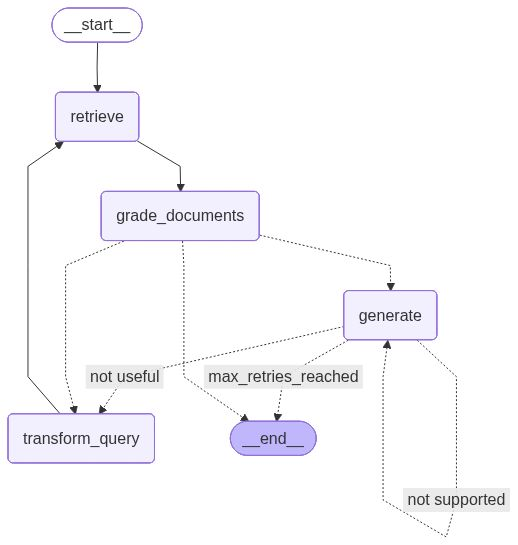

In [19]:
builder = StateGraph(GraphState)

# 노드 추가
builder.add_node("retrieve", retrieve)
builder.add_node("grade_documents", grade_documents)
builder.add_node("generate", generate)
builder.add_node("transform_query", transform_query)

# 엣지 연결
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade_documents")

# 조건부 엣지
builder.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    }
)

builder.add_edge("transform_query", "retrieve")

builder.add_conditional_edges(
    "generate",
    grade_generation,
    {
        "not supported": "generate",
        "not useful": "transform_query",
        "useful": END,
        "max_retries_reached": END,
    }
)

# 체크포인터 추가
self_rag_graph = builder.compile(checkpointer=InMemorySaver())

# 그래프 시각화
from IPython.display import Image, display
display(Image(self_rag_graph.get_graph().draw_mermaid_png()))

`(4) 그래프 실행`

In [20]:
inputs = {"question": "이 식당의 시그니처 메뉴와 가격을 알려주세요"}
config = {"configurable": {"thread_id": "user_123"}}
final_output = self_rag_graph.invoke(inputs, config=config)

INFO:__main__:📚 문서 검색 시작
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:🔍 쿼리 분석 결과: complexity='simple'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:📊 검색 완료: 3/3 문서 반환
INFO:__main__:🔍 문서 관련성 평가
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 3.94초 | 결과: yes
INFO:__main__:✅ 관련 문서 (신뢰도: 0.95)
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.56초 | 결과: yes
INFO:__main__:✅ 관련 문서 (신뢰도: 0.95)
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.59초 | 결과: yes
INFO:__main__:✅ 관련 문서 (신뢰도: 0.95)
INFO:__main__:💡 답변 생성
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200

In [22]:
# 최종 답변 
print(final_output["generation"])

이 식당의 시그니처 메뉴는 "시그니처 스테이크"이며, 가격은 ₩35,000입니다.


In [23]:
inputs = {"question": "김치찌개 메뉴가 있나요?"}
final_output = self_rag_graph.invoke(inputs, config=config)

INFO:__main__:📚 문서 검색 시작
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:🔍 쿼리 분석 결과: complexity='simple'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:📊 검색 완료: 3/3 문서 반환
INFO:__main__:🔍 문서 관련성 평가
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 1.83초 | 결과: no
INFO:__main__:❌ 무관한 문서
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.33초 | 결과: no
INFO:__main__:❌ 무관한 문서
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:⏱️ 평가 시간: 2.35초 | 결과: no
INFO:__main__:❌ 무관한 문서
INFO:__main__:📝 관련 문서 없음, 질문 개선 필요
INFO:__main__:✏️ 질문 최적화
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✏️ 질문 개선: '김치찌개 메뉴가 있나요?' → '김치찌개 메뉴 유무 확인'
INFO:__main__:📚 문서 검색 시작
IN

In [24]:
# 최종 답변
print(final_output["generation"])

제공된 문맥에 김치찌개 메뉴 제공 여부에 대한 정보가 없습니다. 따라서 확인이 불가능합니다.


---
### **[실습]**

- State, Node, Edge를 직접 구성하여, Self RAG 시스템을 구현합니다. 
- 그래프 구현을 통해 RAG 품질을 개선하는 과정을 이해합니다.
- 데이터:
    - data/housing_leasing_law.pdf
    - data/labor_law.pdf
    - data/personal_info_law.pdf

In [ ]:
# 여기에 코드를 작성하세요.